In [2]:

import lightkurve as lk
import matplotlib.pyplot as plt


D:\NASA TESS analysis\.venv\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [4]:
search = lk.search_targetpixelfile("TIC 259191926",mission="TESS")
print(search)

SearchResult containing 3 data products.

 #     mission     year   author  exptime target_name distance
                                     s                 arcsec 
--- -------------- ---- --------- ------- ----------- --------
  0 TESS Sector 57 2022      SPOC     120   259191926      0.0
  1 TESS Sector 57 2022 TESS-SPOC     200   259191926      0.0
  2 TESS Sector 84 2024 TESS-SPOC     200   259191926      0.0


In [5]:

tpf = search[1].download()
mask = tpf.create_threshold_mask(threshold=5)


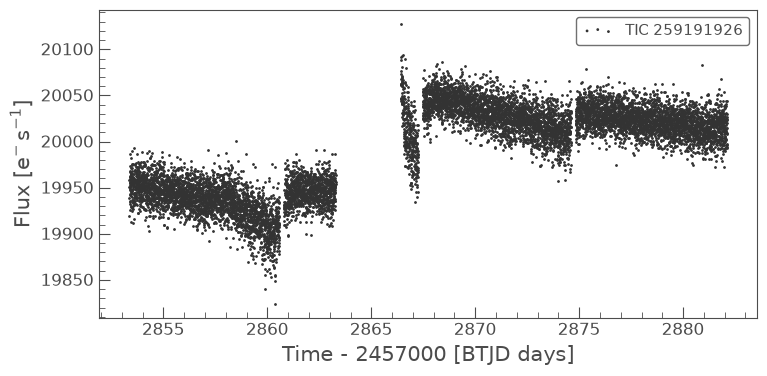

In [6]:
lc = tpf.to_lightcurve(aperture_mask=mask)
lc.scatter()
plt.show()

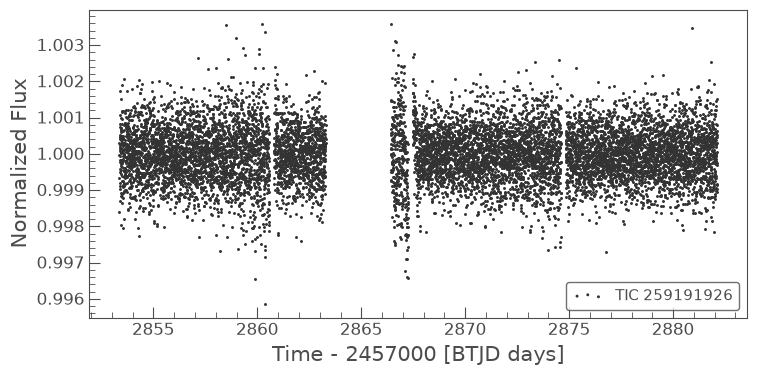

In [8]:
clean = lc.remove_nans()
filtered = clean.remove_outliers()


flatten = filtered.flatten(window_length=301, break_tolerance=100)



flatten.scatter(s=5)
plt.show()


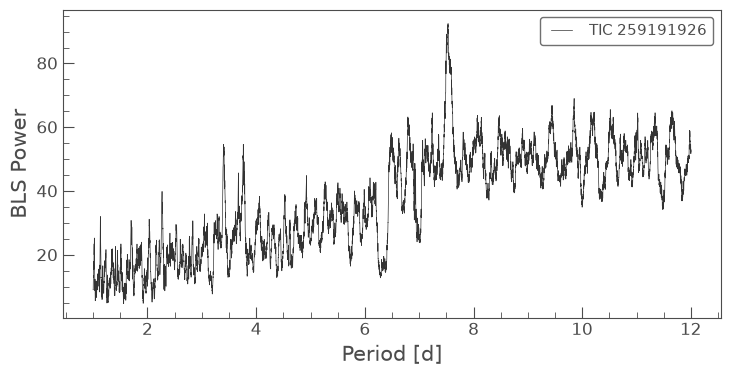

In [9]:
import numpy as np

periodogram = flatten.to_periodogram(method = 'bls', period = np.arange(1,12,0.001))

periodogram.plot()
plt.show()


In [10]:
best_period = periodogram.period_at_max_power
best_t0 = periodogram.transit_time_at_max_power

print("Best period:", best_period)
print("Best t0:", best_t0)

Best period: 7.52799999999928 d
Best t0: 2859.6543720812488


In [11]:
import numpy as np


periods = periodogram.period.value
powers = periodogram.power.value


top_indices = np.argsort(powers)[-5:][::-1]


print("--- TOP 5 HIGHEST PERIODOGRAM PEAKS ---")
for i, idx in enumerate(top_indices, 1):
    print(f"Rank {i} -> Period: {periods[idx]:.4f} days | Power: {powers[idx]:.4f}")


--- TOP 5 HIGHEST PERIODOGRAM PEAKS ---
Rank 1 -> Period: 7.5280 days | Power: 92.4964
Rank 2 -> Period: 7.5290 days | Power: 92.4964
Rank 3 -> Period: 7.5300 days | Power: 92.4964
Rank 4 -> Period: 7.5250 days | Power: 92.0579
Rank 5 -> Period: 7.5240 days | Power: 92.0579


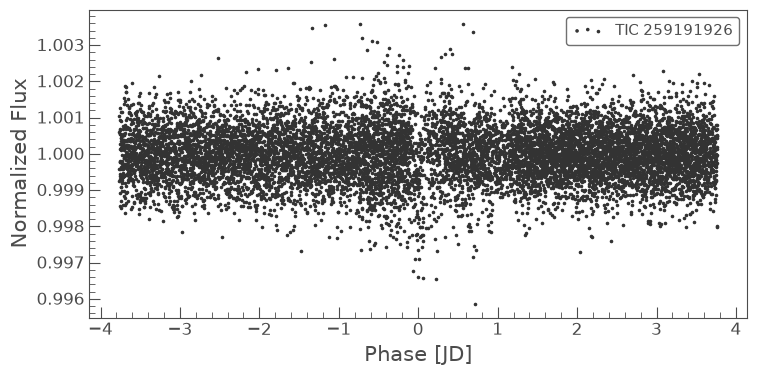

In [12]:
folded_lc = flatten.fold(period=best_period,epoch_time=best_t0)
folded_lc.scatter(s=10)
plt.show()

D:\NASA TESS analysis\.venv\Lib\site-packages\lightkurve\lightcurve.py:3510: UserWarning: n_bins is no longer accepted for FoldedLightCurve objects. Please specify 'bins' instead
  warnings.warn(


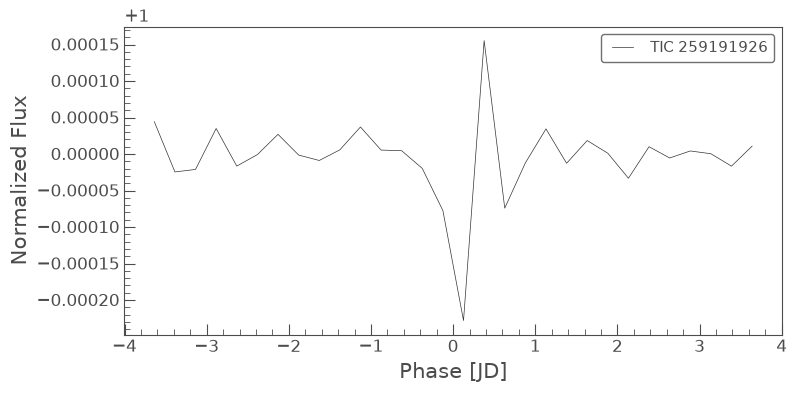

In [18]:

binned = folded_lc.bin(n_bins=30)


binned.plot()

plt.show()